# GHSL — population projection to 2100 (GHS-WUP, R2025A)

The R2025A **GHS-WUP** (World Urbanization Prospects) family projects population and built-up forward to 2100. Here we pull GHS-WUP-POP at two epochs — **2025** and **2100** — over a Portugal-sized AOI and compare. WUP is whole-globe 1 km (no tiles), so each epoch downloads the global file once and crops.

> Code cells are `NBVAL_SKIP` (whole-globe downloads); the saved outputs are real.

In [1]:
# NBVAL_SKIP
import tempfile
from pathlib import Path
from earthlens import EarthLens
out = tempfile.mkdtemp()
paths = EarthLens(
    data_source='ghsl', variables=['GHS_WUP_POP'],
    start='2025-01-01', end='2100-12-31', epochs=[2025, 2100],
    release='R2025A', aoi=[-9.6, 36.9, -6.0, 42.2], path=out,
).download(progress_bar=False)
[p.name for p in paths]

2026-05-29 00:34:52 | INFO | pyramids.base.config | Logging is configured.


['GHS_WUP_POP_E2025_1km_epsg4326.tif', 'GHS_WUP_POP_E2100_1km_epsg4326.tif']

Compare projected population in 2025 vs 2100:

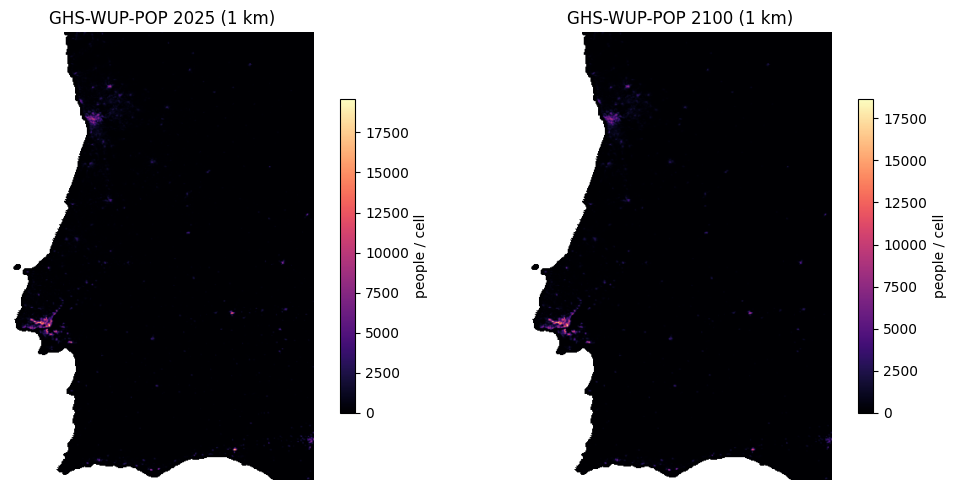

In [2]:
# NBVAL_SKIP
import numpy as np, matplotlib.pyplot as plt
from pyramids.dataset import Dataset
def _load(p):
    a = np.asarray(Dataset.read_file(str(p)).read_array(), dtype='float32')
    a = a[0] if a.ndim == 3 else a
    return np.where(a < 0, np.nan, a)
by_epoch = {('2025' if '_E2025' in p.name else '2100'): _load(p) for p in paths}
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, year in zip(axes, ['2025', '2100']):
    im = ax.imshow(by_epoch[year], cmap='magma')
    ax.set_title(f'GHS-WUP-POP {year} (1 km)'); ax.axis('off')
    fig.colorbar(im, ax=ax, shrink=0.7, label='people / cell')
plt.tight_layout(); plt.show()

Projected change in total population across the AOI, 2025 → 2100:

In [3]:
# NBVAL_SKIP
tot = {y: float(np.nansum(a)) for y, a in by_epoch.items()}
print(f"2025: {tot['2025']:,.0f}  ->  2100: {tot['2100']:,.0f}")
print(f"change: {tot['2100'] - tot['2025']:+,.0f}")

2025: 12,488,454  ->  2100: 9,742,062
change: -2,746,392
